In [13]:
import pandas as pd
import numpy as np
import glob 
import os
import matplotlib.pyplot as plt

### Load all sector files

In [14]:
path="data/"
files = glob.glob(os.path.join(path,"*.xlsx"))

df_list=[]



In [15]:
len(files)

13

In [16]:
files

['data\\BANKING_MFI_Divergence.xlsx',
 'data\\DEVBANK_MFI_Divergence.xlsx',
 'data\\FINANCE_MFI_Divergence.xlsx',
 'data\\HOTELS_MFI_Divergence.xlsx',
 'data\\HYDROPOWER_MFI_Divergence.xlsx',
 'data\\INVESTMENT_MFI_Divergence.xlsx',
 'data\\LIFEINSU_MFI_Divergence.xlsx',
 'data\\MANUFACTURE_MFI_Divergence.xlsx',
 'data\\MICROFINANCE_MFI_Divergence.xlsx',
 'data\\NEPSE_MFI_Divergence.xlsx',
 'data\\NONLIFEINSU_MFI_Divergence.xlsx',
 'data\\OTHERS_MFI_Divergence.xlsx',
 'data\\TRADING_MFI_Divergence.xlsx']

In [17]:
for f in files:
    temp=pd.read_excel(f)
    sector_name = os.path.splitext(os.path.basename(f))[0]
    sector_name= sector_name.replace("_MFI_Divergence","")
    temp["Sector"] = sector_name
    df_list.append(temp)

In [18]:
df = pd.concat(df_list, ignore_index=True)

In [19]:
df.head(5)

,Sector,Pattern,Interval,Start Index,EndIndex,Price Now,Price After Interval,Percentage Change
0,BANKING,Regular Bullish,5,308,313,1308.25,1371.78,4.856105
1,BANKING,Regular Bullish,10,308,318,1308.25,1367.31,4.514428
2,BANKING,Regular Bullish,20,308,328,1308.25,1422.45,8.729218
3,BANKING,Regular Bullish,40,308,348,1308.25,1338.82,2.336709
4,BANKING,Regular Bullish,60,308,368,1308.25,1272.91,-2.701319


In [21]:
df_long = df[["Pattern","Sector","Interval","Percentage Change"]].copy()

In [22]:
df_long.rename(columns = {
    "Pattern Type":"Pattern",
    "Interval (Candles)":"Interval",
    "Percentage Change":"Percent Change"
},inplace=True)

### Hit Rate Function


In [23]:
#Bullish  -> hit if %change > 0
#Bearish -> hit if %change <0

def hit_rate(series,pattern):
    pattern_l = str(pattern).lower()

    if "bear" in pattern_l:
        return (series<0).mean()
    else:
        return (series>0).mean()

### Geomean, stdev, risk-adjusted return


In [24]:
def geomean(series):
    return np.exp(np.log1p(series/100).mean())-1

def risk_adjusted(series):
    gm=geomean(series)
    sd=series.std()/100
    return gm/sd if sd !=0 else np.nan

### Final summary for all the sector

In [25]:
summary = df_long.groupby(["Pattern","Interval"]).apply(
    lambda x : pd.Series({
        "HitRate":hit_rate(x["Percent Change"],x["Pattern"]),
        "Geomean" : geomean(x["Percent Change"]),
        "StDev" : x["Percent Change"].std()/100,
        "RAR" : risk_adjusted(x["Percent Change"])
    })
).reset_index()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29168\415203814.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df_long.groupby(["Pattern","Interval"]).apply(


In [26]:
summary

,Pattern,Interval,HitRate,Geomean,StDev,RAR
0,Hidden Bearish,5,1.000000,-0.037702,0.021206,-1.777952
1,Hidden Bearish,10,1.000000,-0.043254,0.021973,-1.968546
2,Hidden Bearish,20,0.728395,-0.035908,0.071950,-0.499075
3,Hidden Bearish,40,0.506173,0.001199,0.125096,0.009586
4,Hidden Bearish,60,0.419753,-0.000337,0.145077,-0.002326
5,Hidden Bullish,5,1.000000,0.050742,0.036654,1.384353
6,Hidden Bullish,10,1.000000,0.065351,0.064441,1.014116
7,Hidden Bullish,20,0.707692,0.075091,0.123646,0.607303
8,Hidden Bullish,40,0.615385,0.063985,0.143550,0.445729
9,Hidden Bullish,60,0.692308,0.064129,0.134895,0.475404


In [27]:
patterns = summary["Pattern"].unique()

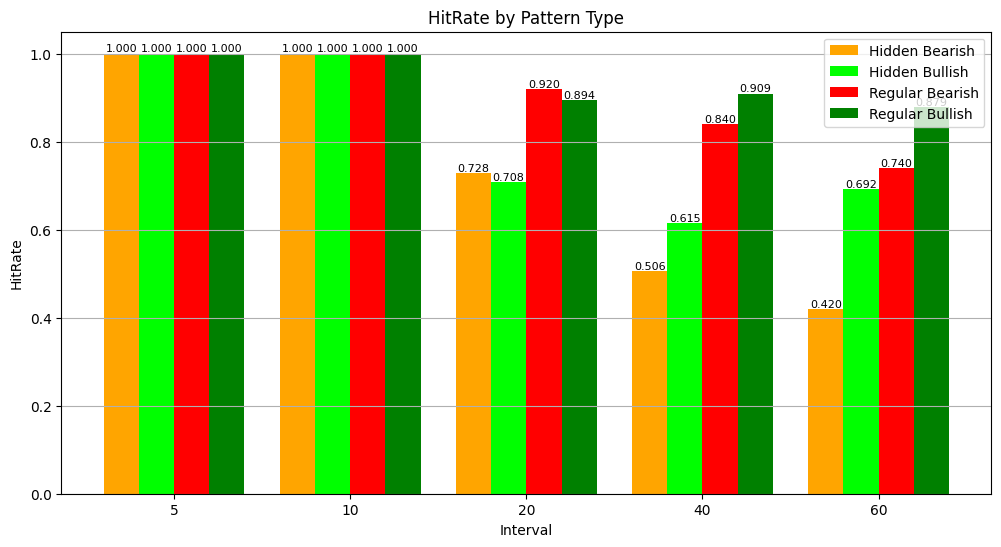

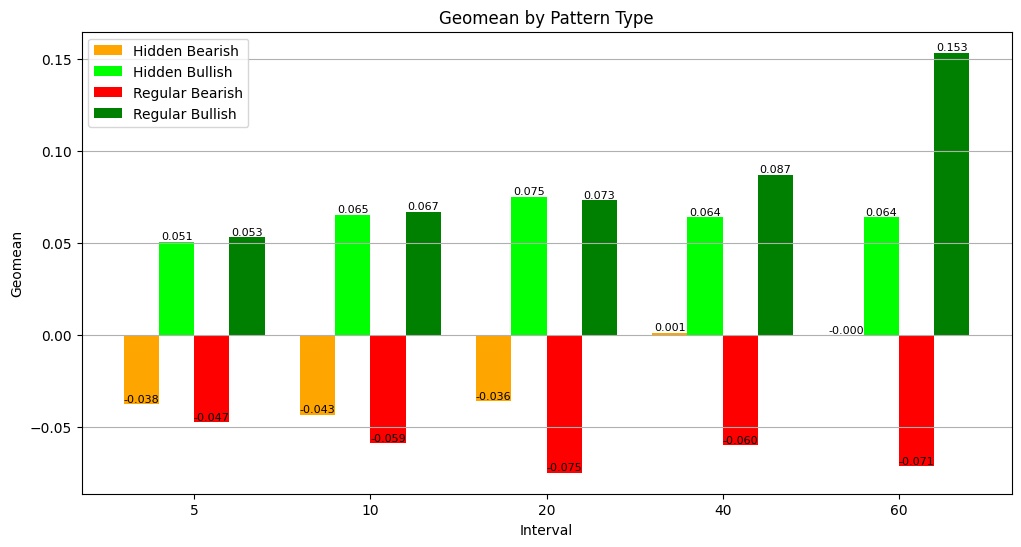

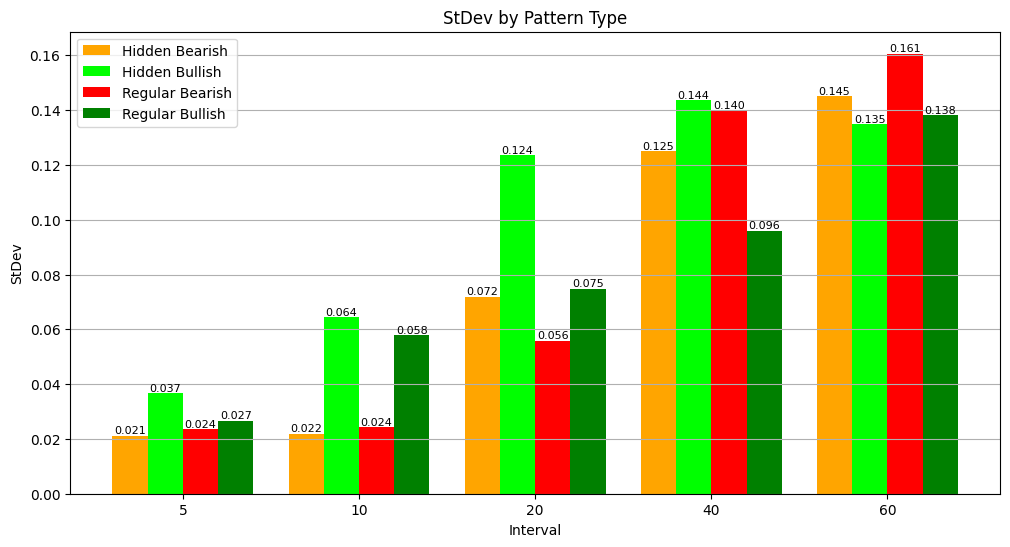

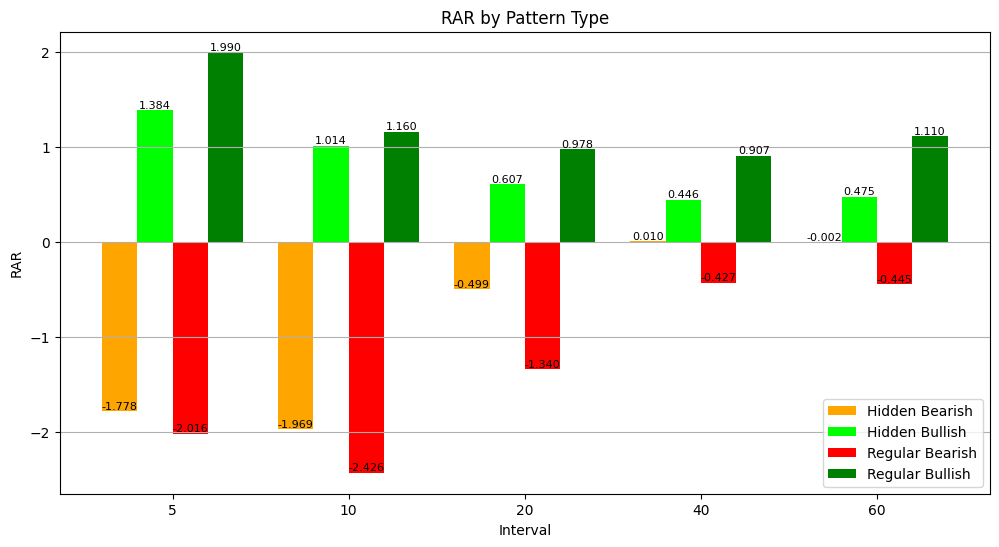

In [28]:

metrics = ["HitRate", "Geomean", "StDev", "RAR"]
patterns = summary["Pattern"].unique()
intervals = sorted(summary["Interval"].unique())

color_map={
    "Regular Bullish":"green",
    "Regular Bearish":"red",
    "Hidden Bullish":"lime",
    "Hidden Bearish":"orange"
}

x = np.arange(len(intervals))
width = 0.20

for metric in metrics:
    plt.figure(figsize=(12,6))

    for i, p in enumerate(patterns):
        subset = summary[summary["Pattern"] == p].sort_values("Interval")
        values = subset[metric].values

        color=color_map.get(p , "gray")
        bars = plt.bar(x + i*width, values, width, label=p,color=color)

        # label each bar
        for bar in bars:
            h = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                h,
                f"{h:.3f}",
                ha='center',
                va='bottom',
                fontsize=8
            )

    plt.xticks(x + width * (len(patterns)-1)/2, intervals)
    plt.xlabel("Interval")
    plt.ylabel(metric)
    plt.title(f"{metric} by Pattern Type")
    plt.legend()
    plt.grid(axis='y')
    plt.show()
